# Member 3 — Random Forest & Class Imbalance Analysis
**Group 4 — Machine Learning | Customer Churn Prediction & Business Intelligence System**

**Branch:** `member3-ml-random-forest`
**Owner:** Member 3

## Scope (what this notebook covers)
- Random Forest initial model (default/reference)
- Random Forest cross-validation using the shared Group 4 folds/settings
- Random Forest hyperparameter tuning
- Primary class-imbalance investigation for Group 4 (natural vs class-weighted vs optional SMOTE)
- Random Forest feature-importance analysis (supporting evidence only, not causal)
- Saving Member 3 outputs, figures, and (optional) candidate model artifact

## Out of scope (owned by other members)
- Logistic Regression / Dummy baseline / shared foundation → Member 1
- Decision Tree / common evaluation-plotting framework → Member 2
- XGBoost / boosting-specific tuning → Member 4
- Declaring the final winning model (decided by all 4 members after integration)

## Note on data used in this run
The Group 3 "feature-engineered" handoff file referenced in the Member 3 execution guide includes four
additional engineered columns (`Fiber_Monthly_Risk`, `New_High_Spend`, `New_Monthly_Customer`,
`Security_Tech_Bundle`). Those columns were **not present** in the dataset available for this run
(`customer_churn_cleaned.xlsx`, sheet `Model_Ready_Data`). This notebook proceeds with the **17 core
features that are available** or, and documents this limitation clearly in the Handoff Summary (Section 14)
so the team can re-run this notebook once the full engineered feature set is merged, without changing any
other part of the protocol.


## 2. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded. RANDOM_STATE =", RANDOM_STATE)


Libraries loaded. RANDOM_STATE = 42


## 3. Load & Validate Data
Loads the Group 3 handoff file from the agreed repository-relative path and validates the target
column and the leakage blacklist (`Churn Label`, `Churn Score`, `Churn Reason` must never be used as
predictors).

In [2]:
DATA_PATH = "../../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)

TARGET = "Churn Value"
assert TARGET in df.columns, f"Target column '{TARGET}' not found!"

LEAKAGE_BLACKLIST = ["Churn Label", "Churn Score", "Churn Reason"]
leak_found = [c for c in LEAKAGE_BLACKLIST if c in df.columns]
assert len(leak_found) == 0, f"Leakage columns present in dataset: {leak_found}"
print("Leakage check passed — none of", LEAKAGE_BLACKLIST, "are present.")

print("\nClass distribution:")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(4) * 100)


Shape: (7043, 23)
Leakage check passed — none of ['Churn Label', 'Churn Score', 'Churn Reason'] are present.

Class distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64
Churn Value
0    73.46
1    26.54
Name: proportion, dtype: float64


## 4. Reuse Common Group 4 Protocol
Core feature list, 80/20 stratified split, and 5-fold StratifiedKFold — matching the shared Group 4
settings (`random_state=42`) so results are directly comparable with Logistic Regression, Decision Tree,
and XGBoost branches.

Columns dropped: `Zip Code` (identifier, not predictive), `Total Frequency` (removed as redundant per
protocol), `CLTV` (removed — near-perfect correlation with `Total Charges`, per protocol).
`Gender` and `Phone Service` are excluded as low-priority features (not part of the agreed common
feature experiment).

In [3]:
DROP_COLS = ["Zip Code", "Total Frequency", "CLTV", "Gender", "Phone Service"]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

CORE_FEATURES = [c for c in df.columns if c not in DROP_COLS + [TARGET]]
print("Core features used (%d):" % len(CORE_FEATURES))
print(CORE_FEATURES)

X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

CATEGORICAL_COLS = [c for c in X.columns if pd.api.types.is_string_dtype(X[c]) or pd.api.types.is_object_dtype(X[c])]
NUMERIC_COLS = [c for c in X.columns if c not in CATEGORICAL_COLS]
print("\nCategorical columns:", CATEGORICAL_COLS)
print("Numeric/already-encoded columns:", NUMERIC_COLS)

# Shared 80/20 stratified split, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), " Test churn rate:", y_test.mean().round(4))

# Shared 5-fold StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Preprocessing: one-hot encode categoricals inside the pipeline (fit on train folds only)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CATEGORICAL_COLS),
    ],
    remainder="passthrough"
)

SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


Core features used (17):
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']

Categorical columns: ['Internet Service', 'Contract']
Numeric/already-encoded columns: ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']

Train shape: (5634, 17)  Test shape: (1409, 17)
Train churn rate: 0.2654  Test churn rate: 0.2654


## 5–6. Initial Random Forest (Reference Model) + CV Evaluation
A simple, reproducible reference model under the **natural class distribution** — no balancing yet.
`n_estimators=200` is a sensible fixed value for the reference (not a search).

In [4]:
initial_rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ))
])

initial_cv_results = cross_validate(
    initial_rf, X_train, y_train, cv=cv, scoring=SCORING, return_train_score=False, n_jobs=-1
)

def summarize_cv(cv_results, label):
    row = {"model_name": label}
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        scores = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()
    return row

initial_summary = summarize_cv(initial_cv_results, "RF_initial_natural")
print("Initial Random Forest — 5-fold CV results (mean ± std):")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {metric:10s}: {initial_summary[metric+'_mean']:.4f} ± {initial_summary[metric+'_std']:.4f}")


Initial Random Forest — 5-fold CV results (mean ± std):
  accuracy  : 0.7964 ± 0.0097
  precision : 0.6443 ± 0.0240
  recall    : 0.5204 ± 0.0209
  f1        : 0.5756 ± 0.0205
  roc_auc   : 0.8366 ± 0.0079


## 7. Imbalance Diagnosis
Target distribution and what the initial (natural-distribution) model achieves for churn Recall/Precision
— this is the baseline the imbalance-treatment experiments must beat to be justified.

In [5]:
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100
print("Class 0 (non-churn):", class_counts[0], f"({class_pct[0]:.2f}%)")
print("Class 1 (churn):    ", class_counts[1], f"({class_pct[1]:.2f}%)")

print("\nInitial RF (natural distribution) churn-class performance from CV above:")
print(f"  Recall (churn detection): {initial_summary['recall_mean']:.4f} ± {initial_summary['recall_std']:.4f}")
print(f"  Precision (churn flags reliable): {initial_summary['precision_mean']:.4f} ± {initial_summary['precision_std']:.4f}")
print("\nDataset is imbalanced (~73/27) but not extreme. This motivates testing class weighting")
print("before considering SMOTE, rather than assuming balancing is required.")


Class 0 (non-churn): 5174 (73.46%)
Class 1 (churn):     1869 (26.54%)

Initial RF (natural distribution) churn-class performance from CV above:
  Recall (churn detection): 0.5204 ± 0.0209
  Precision (churn flags reliable): 0.6443 ± 0.0240

Dataset is imbalanced (~73/27) but not extreme. This motivates testing class weighting
before considering SMOTE, rather than assuming balancing is required.


## 8–9. Class Imbalance Experiments: Natural vs Class-Weighted vs SMOTE
All strategies evaluated under the **same 5-fold StratifiedKFold** on the **same training data** for a
fair comparison. SMOTE is applied **only inside training folds** via an imbalanced-learn `Pipeline`,
never on the full dataset — this prevents synthetic samples from leaking into validation folds.

In [6]:
results_rows = [initial_summary]

# --- Strategy B: class_weight='balanced' ---
rf_balanced = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
    ))
])
cv_balanced = cross_validate(rf_balanced, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
results_rows.append(summarize_cv(cv_balanced, "RF_class_weight_balanced"))

# --- Strategy B2: class_weight='balanced_subsample' ---
rf_balanced_sub = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"
    ))
])
cv_balanced_sub = cross_validate(rf_balanced_sub, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
results_rows.append(summarize_cv(cv_balanced_sub, "RF_class_weight_balanced_subsample"))

# --- Strategy C: SMOTE inside training folds only (leakage-safe) ---
rf_smote = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])
cv_smote = cross_validate(rf_smote, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
results_rows.append(summarize_cv(cv_smote, "RF_SMOTE_leakage_safe"))

imbalance_df = pd.DataFrame(results_rows)
imbalance_df["imbalance_strategy"] = ["natural", "class_weight_balanced", "class_weight_balanced_subsample", "smote"]
display_cols = ["model_name", "imbalance_strategy", "accuracy_mean", "precision_mean", "recall_mean",
                 "f1_mean", "roc_auc_mean", "recall_std", "precision_std"]
print(imbalance_df[display_cols].round(4).to_string(index=False))


                        model_name              imbalance_strategy  accuracy_mean  precision_mean  recall_mean  f1_mean  roc_auc_mean  recall_std  precision_std
                RF_initial_natural                         natural         0.7964          0.6443       0.5204   0.5756        0.8366      0.0209         0.0240
          RF_class_weight_balanced           class_weight_balanced         0.7962          0.6482       0.5090   0.5701        0.8377      0.0172         0.0271
RF_class_weight_balanced_subsample class_weight_balanced_subsample         0.7959          0.6473       0.5077   0.5689        0.8374      0.0235         0.0295
             RF_SMOTE_leakage_safe                           smote         0.7913          0.6254       0.5331   0.5754        0.8352      0.0205         0.0221


**Reading the comparison:** compare each strategy's `recall_mean` (fewer missed churners) against
its `precision_mean` (fewer false retention-offer alarms) relative to the natural-distribution baseline.
A strategy is only worth adopting if it improves churn Recall/F1 **without an unacceptable Precision
collapse** — class balance is a means to that end, not a goal in itself.

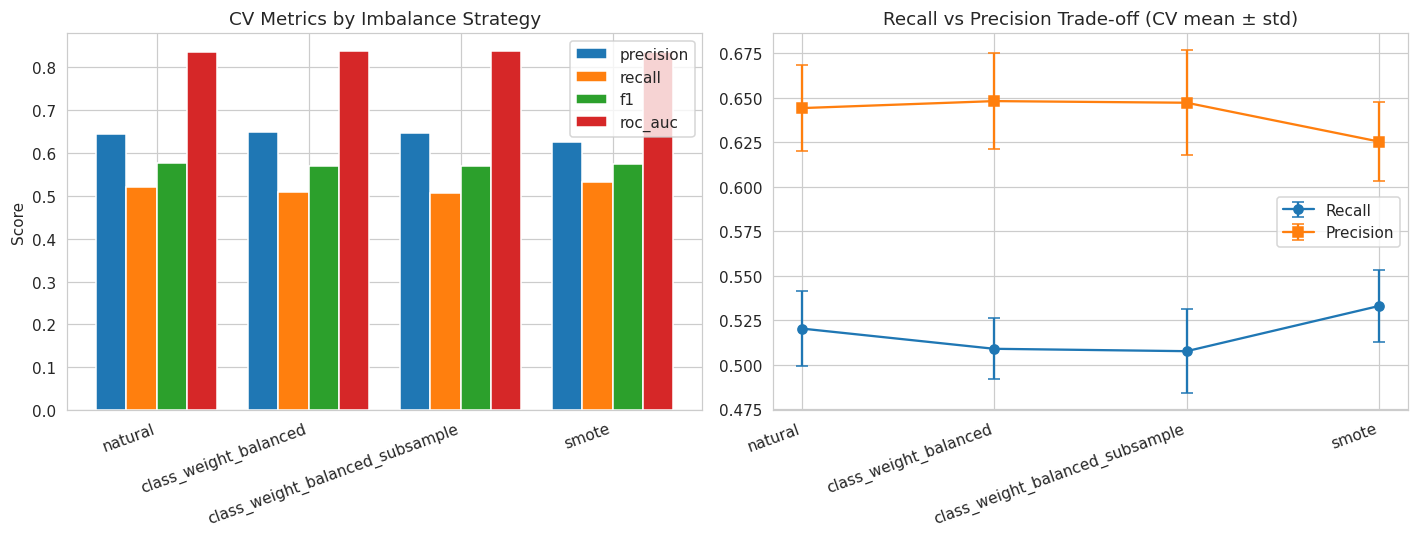

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_to_plot = ["precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]
x = np.arange(len(imbalance_df))
width = 0.2
for i, m in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, imbalance_df[m], width, label=m.replace("_mean", ""))
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(imbalance_df["imbalance_strategy"], rotation=20, ha="right")
axes[0].set_title("CV Metrics by Imbalance Strategy")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].errorbar(imbalance_df["imbalance_strategy"], imbalance_df["recall_mean"],
                  yerr=imbalance_df["recall_std"], fmt="o-", label="Recall", capsize=4)
axes[1].errorbar(imbalance_df["imbalance_strategy"], imbalance_df["precision_mean"],
                  yerr=imbalance_df["precision_std"], fmt="s-", label="Precision", capsize=4)
axes[1].set_xticklabels(imbalance_df["imbalance_strategy"], rotation=20, ha="right")
axes[1].set_title("Recall vs Precision Trade-off (CV mean ± std)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/member3_random_forest_imbalance_comparison.png", bbox_inches="tight")
plt.show()


In [8]:
# Pick the best imbalance strategy by F1 (balances the recall/precision trade-off), tie-break on recall
best_strategy_row = imbalance_df.sort_values(["f1_mean", "recall_mean"], ascending=False).iloc[0]
print("Recommended imbalance strategy based on CV evidence:", best_strategy_row["imbalance_strategy"])
print(best_strategy_row[display_cols])


Recommended imbalance strategy based on CV evidence: natural
model_name            RF_initial_natural
imbalance_strategy               natural
accuracy_mean                   0.796416
precision_mean                  0.644251
recall_mean                     0.520401
f1_mean                         0.575609
roc_auc_mean                    0.836603
recall_std                      0.020897
precision_std                   0.024031
Name: 0, dtype: object


## 10. Hyperparameter Tuning (Controlled, Reproducible)
`RandomizedSearchCV` on **training/CV data only**, using the imbalance strategy selected above.
Scoring metric: **F1** (business-relevant balance of Recall/Precision, not Accuracy alone), while still
reporting all required metrics for the winning configuration.

In [9]:
from scipy.stats import randint

chosen_strategy = best_strategy_row["imbalance_strategy"]
print("Tuning uses imbalance strategy:", chosen_strategy)

if chosen_strategy == "smote":
    tuning_pipeline = ImbPipeline(steps=[
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])
elif chosen_strategy in ("class_weight_balanced", "class_weight_balanced_subsample"):
    cw = "balanced" if chosen_strategy == "class_weight_balanced" else "balanced_subsample"
    tuning_pipeline = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw))
    ])
else:
    tuning_pipeline = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])

param_distributions = {
    "clf__n_estimators": randint(150, 500),
    "clf__max_depth": [None, 6, 8, 10, 14, 20],
    "clf__min_samples_split": randint(2, 12),
    "clf__min_samples_leaf": randint(1, 8),
    "clf__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)

search.fit(X_train, y_train)

print("Best CV F1 score:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Tuning uses imbalance strategy: natural


Best CV F1 score: 0.6037
Best params:
  clf__max_depth: 10
  clf__max_features: sqrt
  clf__min_samples_leaf: 3
  clf__min_samples_split: 6
  clf__n_estimators: 456


In [10]:
best_rf_pipeline = search.best_estimator_

tuned_cv = cross_validate(best_rf_pipeline, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
tuned_summary = summarize_cv(tuned_cv, "RF_tuned_" + chosen_strategy)
tuned_summary["best_params"] = str(search.best_params_)
tuned_summary["search_score"] = search.best_score_

print("Tuned Random Forest — 5-fold CV results (mean ± std):")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {metric:10s}: {tuned_summary[metric+'_mean']:.4f} ± {tuned_summary[metric+'_std']:.4f}")

tuning_results_df = pd.DataFrame([{
    "model_name": "RF_untuned_" + "natural",
    "imbalance_strategy": "natural",
    **{k: v for k, v in initial_summary.items() if k != "model_name"},
    "best_params": None,
    "search_score": None,
}, {
    "model_name": "RF_tuned_" + chosen_strategy,
    "imbalance_strategy": chosen_strategy,
    **{k: v for k, v in tuned_summary.items() if k not in ("model_name", "best_params", "search_score")},
    "best_params": str(search.best_params_),
    "search_score": search.best_score_,
}])
print(tuning_results_df.round(4).to_string(index=False))


Tuned Random Forest — 5-fold CV results (mean ± std):
  accuracy  : 0.8106 ± 0.0143
  precision : 0.6796 ± 0.0367
  recall    : 0.5438 ± 0.0303
  f1        : 0.6037 ± 0.0290
  roc_auc   : 0.8589 ± 0.0101
        model_name imbalance_strategy  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std  roc_auc_mean  roc_auc_std                                                                                                                            best_params  search_score
RF_untuned_natural            natural         0.7964        0.0097          0.6443         0.0240       0.5204      0.0209   0.5756  0.0205        0.8366       0.0079                                                                                                                                    NaN           NaN
  RF_tuned_natural            natural         0.8106        0.0143          0.6796         0.0367       0.5438      0.0303   0.6037  0.0290        0.8589       0.01

## 11. Final Member 3 Candidate — Fit on Full Training Set, Evaluate on Held-out Test Set
The held-out test set was **not used** for any tuning or model-selection decision above — used here
only for a final, single-pass evaluation, per the Group 4 protocol.

In [11]:
best_rf_pipeline.fit(X_train, y_train)

y_pred = best_rf_pipeline.predict(X_test)
y_proba = best_rf_pipeline.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
print("Final Member 3 Random Forest candidate — held-out test performance:")
for k, v in test_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

# Train-CV gap check (generalization)
train_pred = best_rf_pipeline.predict(X_train)
train_f1 = f1_score(y_train, train_pred)
print(f"\nTrain F1: {train_f1:.4f} vs CV F1 mean: {tuned_summary['f1_mean']:.4f} "
      f"(gap: {train_f1 - tuned_summary['f1_mean']:.4f}) — large gaps suggest overfitting.")


Final Member 3 Random Forest candidate — held-out test performance:
  accuracy  : 0.8027
  precision : 0.6600
  recall    : 0.5294
  f1        : 0.5875
  roc_auc   : 0.8534



Train F1: 0.7003 vs CV F1 mean: 0.6037 (gap: 0.0965) — large gaps suggest overfitting.


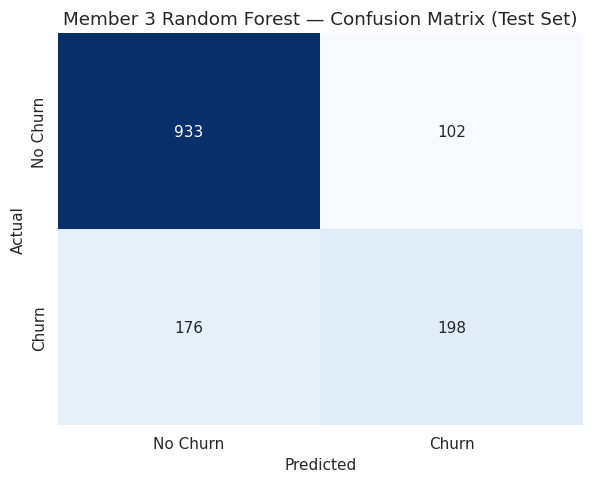

True Negatives:  933
False Positives: 102  (flagged as churn risk, but stayed)
False Negatives: 176  (missed actual churners — costliest business error)
True Positives:  198


In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Member 3 Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../figures/member3_random_forest_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}  (flagged as churn risk, but stayed)")
print(f"False Negatives: {fn}  (missed actual churners — costliest business error)")
print(f"True Positives:  {tp}")


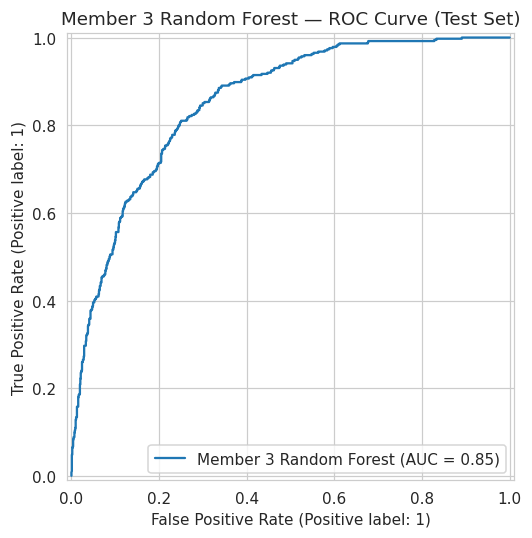

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Member 3 Random Forest")
ax.set_title("Member 3 Random Forest — ROC Curve (Test Set)")
plt.tight_layout()
plt.savefig("../figures/member3_random_forest_roc_curve.png", bbox_inches="tight")
plt.show()


**Business interpretation:** False Negatives (customers who actually churn, predicted as staying)
are the costliest error — they represent churners the business fails to target with retention offers.
The imbalance strategy selected above was chosen specifically to reduce False Negatives (raise Recall)
without an unacceptable rise in False Positives (Precision collapse). The threshold used throughout is
the default 0.50 — no threshold tuning was performed here, per the protocol (any threshold change is a
shared, final-integration decision using training/CV data only).

## 12. Feature Importance — Supporting Analysis Only
Impurity-based `feature_importances_` from the final candidate. **Not causal evidence** — high
importance means the model relied on the feature for prediction, not that the feature causes churn.

In [14]:
ohe = best_rf_pipeline.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_COLS))
passthrough_names = [c for c in X.columns if c not in CATEGORICAL_COLS]
all_feature_names = cat_feature_names + passthrough_names

importances = best_rf_pipeline.named_steps["clf"].feature_importances_
fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Method: impurity-based feature_importances_ (RandomForestClassifier)")
print("NOTE: one-hot expanded categorical levels are not directly comparable in units to")
print("      unencoded numeric features — interpret ranking directionally, not causally.")
print(fi_df.head(15).to_string(index=False))


Method: impurity-based feature_importances_ (RandomForestClassifier)
NOTE: one-hot expanded categorical levels are not directly comparable in units to
      unencoded numeric features — interpret ranking directionally, not causally.
                     feature  importance
               Tenure Months    0.163628
               Total Charges    0.138554
     Contract_Month-to-month    0.129706
             Monthly Charges    0.119611
Internet Service_Fiber optic    0.085190
                  Dependents    0.065531
           Contract_Two year    0.046005
         Internet Service_No    0.032303
              Payment Method    0.025618
           Paperless Billing    0.024987
             Online Security    0.022135
           Contract_One year    0.020092
        Internet Service_DSL    0.019967
                Tech Support    0.018572
                     Partner    0.015007


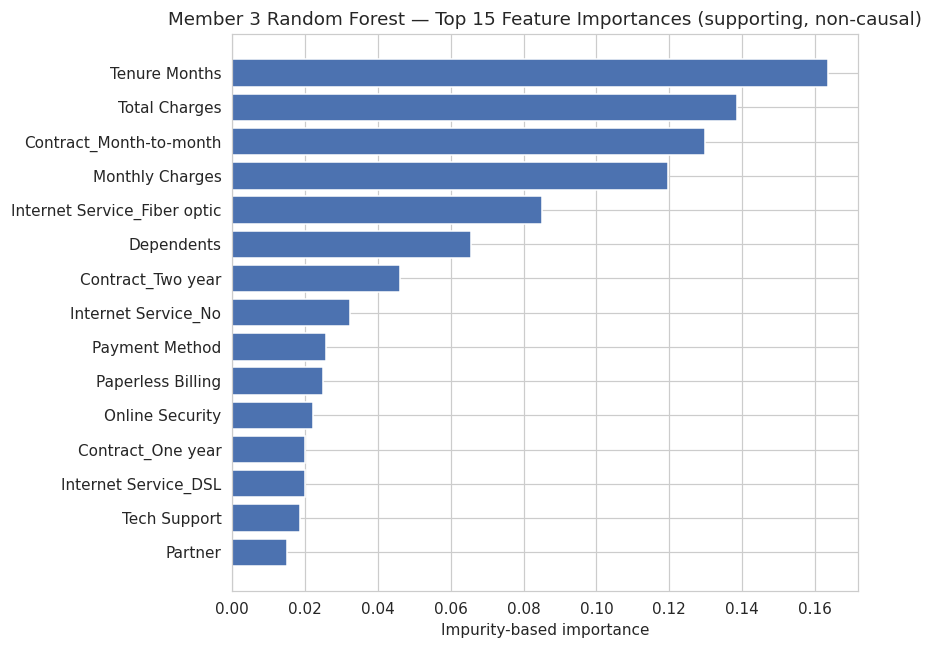

In [15]:
top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
top_fi = fi_df.head(top_n).iloc[::-1]
ax.barh(top_fi["feature"], top_fi["importance"], color="#4C72B0")
ax.set_xlabel("Impurity-based importance")
ax.set_title(f"Member 3 Random Forest — Top {top_n} Feature Importances (supporting, non-causal)")
plt.tight_layout()
plt.savefig("../figures/member3_random_forest_feature_importance.png", bbox_inches="tight")
plt.show()


## 13. Save Member 3 Outputs
CSV outputs, figures (already saved above), and an optional candidate model artifact — using the
agreed Member 3 filenames and column conventions so `model_comparison.csv` can be assembled without
reinterpreting results.

In [16]:
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# --- CV results (initial + tuned) ---
cv_results_df = pd.DataFrame([
    {"model_name": "RF_initial_natural", "stage": "initial", "imbalance_strategy": "natural",
     **{k: v for k, v in initial_summary.items() if k != "model_name"}},
    {"model_name": "RF_tuned_" + chosen_strategy, "stage": "tuned", "imbalance_strategy": chosen_strategy,
     **{k: v for k, v in tuned_summary.items() if k not in ("model_name", "best_params", "search_score")}},
])
cv_results_df.to_csv("../outputs/member3_random_forest_cv_results.csv", index=False)

# --- Tuning results ---
tuning_out = tuning_results_df.copy()
tuning_out.to_csv("../outputs/member3_random_forest_tuning_results.csv", index=False)

# --- Imbalance experiment results ---
imbalance_out = imbalance_df[["model_name", "imbalance_strategy"] + [c for c in imbalance_df.columns
                 if c not in ("model_name", "imbalance_strategy")]]
imbalance_out.to_csv("../outputs/member3_random_forest_imbalance_results.csv", index=False)

# --- Feature importance ---
fi_df.to_csv("../outputs/member3_random_forest_feature_importance.csv", index=False)

# --- Optional candidate model artifact ---
joblib.dump(best_rf_pipeline, "../models/member3_random_forest_candidate.joblib")

print("Saved:")
print(" outputs/member3_random_forest_cv_results.csv")
print(" outputs/member3_random_forest_tuning_results.csv")
print(" outputs/member3_random_forest_imbalance_results.csv")
print(" outputs/member3_random_forest_feature_importance.csv")
print(" figures/member3_random_forest_confusion_matrix.png")
print(" figures/member3_random_forest_roc_curve.png")
print(" figures/member3_random_forest_imbalance_comparison.png")
print(" figures/member3_random_forest_feature_importance.png")
print(" models/member3_random_forest_candidate.joblib")


Saved:
 outputs/member3_random_forest_cv_results.csv
 outputs/member3_random_forest_tuning_results.csv
 outputs/member3_random_forest_imbalance_results.csv
 outputs/member3_random_forest_feature_importance.csv
 figures/member3_random_forest_confusion_matrix.png
 figures/member3_random_forest_roc_curve.png
 figures/member3_random_forest_imbalance_comparison.png
 figures/member3_random_forest_feature_importance.png
 models/member3_random_forest_candidate.joblib


## 14. Handoff Summary — What Group 4 Integration Should Reuse

**Model:** Random Forest (`sklearn.ensemble.RandomForestClassifier`), tuned via `RandomizedSearchCV`
(scoring = F1), 5-fold `StratifiedKFold(shuffle=True, random_state=42)`, 80/20 stratified train/test split
(`random_state=42`).

**Imbalance recommendation:** see `chosen_strategy` printed in Section 10 / the `imbalance_strategy`
column of `member3_random_forest_tuning_results.csv` — chosen by comparing natural distribution vs
`class_weight='balanced'` vs `class_weight='balanced_subsample'` vs leakage-safe SMOTE under identical
CV folds, selecting the strategy with the best F1 (tie-break: Recall).

**Best hyperparameters:** see `best_params` column in `member3_random_forest_tuning_results.csv`.

**Final held-out test metrics:** printed in Section 11 — **not used for any tuning decision**, single
final-pass evaluation only.

**Known limitation to resolve before final integration:** this run used 17 of the 21 documented core
features — `Fiber_Monthly_Risk`, `New_High_Spend`, `New_Monthly_Customer`, and `Security_Tech_Bundle`
were not present in the dataset available for this run. Once Group 3's fully engineered feature file is
merged into the repository, re-run this notebook unchanged (same protocol, same random_state) to confirm
whether these engineered features change the imbalance recommendation or tuned performance.

**Feature importance:** supporting evidence only (impurity-based, non-causal) — see
`member3_random_forest_feature_importance.csv`.

**Not done here (by design):** final model selection across all four branches; classification threshold
tuning; any changes to the shared split/CV/preprocessing protocol.


## 15. Member 3 Definition-of-Done Checklist
- [x] Group 3 dataset and core feature handoff used (see data note in Section 1)
- [x] Common Group 4 80/20 stratified split + 5-fold StratifiedKFold followed (`random_state=42`)
- [x] Initial Random Forest complete (Section 5–6)
- [x] Class imbalance diagnosis complete (Section 7)
- [x] Standard vs class-weighted vs SMOTE Random Forest comparison complete, leakage-safe (Section 8–9)
- [x] Hyperparameter tuning complete and reproducible (Section 10)
- [x] Best RF candidate has CV metrics + best parameters recorded (Section 10–11)
- [x] Recall/Precision/F1 trade-offs interpreted for the business objective (Section 9, 11)
- [x] CV stability/generalization discussed (train-CV gap, Section 11)
- [x] Outputs/figures saved with clear, agreed names (Section 13)
- [x] Notebook designed to run cleanly top-to-bottom
- [ ] PR reviewed and merged into `group4-machine-learning` (team action, not from this notebook)

**Reminder:** Random Forest is *not* declared the final Group 4 model here. After all four branches are
integrated, the team compares Logistic Regression, Decision Tree, Random Forest, and XGBoost using the
same protocol and selects the final model together.
